## 2 线性代数和 NDArray
### 2.1 理论计算题
已知：
向量 $a=[2,-1,3]^\top$，$b=[1,4,-2]^\top$
矩阵 $A=\begin{bmatrix}1&0&2\\-1&3&1\end{bmatrix}$，$B=\begin{bmatrix}2&1\\0&-1\\3&2\end{bmatrix}$

1. **向量点积 $a \cdot b$**
点积公式：对应位置相乘后相加
$$a\cdot b = 2\times1 + (-1)\times4 + 3\times(-2) = 2 - 4 - 6 = -8$$

2. **矩阵乘法 $A \times B$**
矩阵乘法规则：行 × 列 求和
第一行第一列：$1×2 + 0×0 + 2×3 = 2 + 0 + 6 = 8$
第一行第二列：$1×1 + 0×(-1) + 2×2 = 1 + 0 + 4 = 5$
第二行第一列：$-1×2 + 3×0 + 1×3 = -2 + 0 + 3 = 1$
第二行第二列：$-1×1 + 3×(-1) + 1×2 = -1 - 3 + 2 = -2$
结果：
$$AB = \begin{bmatrix}8&5\\1&-2\end{bmatrix}，形状：2×2$$

3. **向量 $a$ 的 Frobenius 范数**
范数公式：各元素平方和开根号
$$\|a\|_F = \sqrt{2^2 + (-1)^2 + 3^2} = \sqrt{4 + 1 + 9} = \sqrt{14} \approx 3.7417$$

In [12]:
# 2.2 线性代数运算
import numpy as np  # 导入数值计算库

# 1. 创建 3×4 标准正态随机矩阵 X
X = np.random.randn(3, 4)

# 2. 创建 4×2 全 1 矩阵 Y
Y = np.ones((4, 2))

# 3. 执行矩阵乘法 Z = X × Y
Z = np.dot(X, Y)

# 4. 输出指定位置元素
print("Z 第一行第二列元素：", Z[0, 1])
print("Z 第二行所有元素：", Z[1])

# 5. 计算 Z 的 Frobenius 范数
z_norm = np.linalg.norm(Z)
print("Z 的 Frobenius 范数：", z_norm)

Z 第一行第二列元素： 1.1308357723493419
Z 第二行所有元素： [-0.84777077 -0.84777077]
Z 的 Frobenius 范数： 2.342180078404503


## 3 概率与统计
### 3.1 理论计算题：贝叶斯公式
定义：
A = 患病，B = 检测阳性
先验概率：$P(A) = 0.001$，$P(\neg A) = 0.999$
条件概率：$P(B|A) = 0.99$，$P(B|\neg A) = 0.02$

贝叶斯公式：
$$P(A|B) = \frac{P(B|A)P(A)}{P(B|A)P(A) + P(B|\neg A)P(\neg A)}$$

代入计算：
分子：$0.99 × 0.001 = 0.00099$
分母：$0.00099 + 0.02 × 0.999 = 0.00099 + 0.01998 = 0.02097$
结果：
$$P(A|B) = \frac{0.00099}{0.02097} ≈ 0.0472$$
即：检测阳性时真正患病概率 ≈ 4.72%

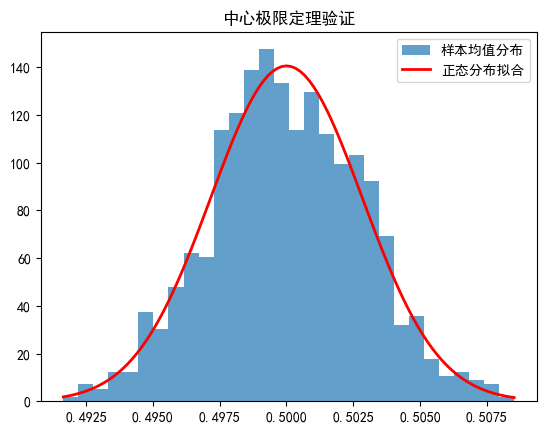

样本均值的实际方差： 8.051805430036408e-06


In [13]:
# 3.2 中心极限定理验证
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# 解决中文乱码问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'WenQuanYi Zen Hei']  # 优先使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题
# 1. 设定参数
n = 10000  # 每次抽样样本数量
m = 1000   # 抽样重复次数

# 2. 生成均匀分布样本，并计算每次的均值
means = [np.mean(np.random.uniform(0, 1, n)) for _ in range(m)]

# 3. 绘制均值分布直方图
plt.hist(means, bins=30, density=True, alpha=0.7, label='样本均值分布')

# 4. 拟合正态分布曲线
mu, sigma = np.mean(means), np.std(means)
x = np.linspace(min(means), max(means), 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label='正态分布拟合')

plt.title('中心极限定理验证')
plt.legend()
plt.show()

# 5. 输出均值的方差
print("样本均值的实际方差：", np.var(means))

## 4 导数、反向传播和复杂度
### 4.1 理论计算题：求梯度
已知：
$z = (w_1x_1 + w_2x_2 - y)^2$
给定：$x_1=2, x_2=1, y=3, w_1=0.5, w_2=1$

1. **求偏导公式**（链式法则）
$$\frac{\partial z}{\partial w_1} = 2x_1(w_1x_1 + w_2x_2 - y)$$
$$\frac{\partial z}{\partial w_2} = 2x_2(w_1x_2 + w_2x_2 - y)$$

2. **代入数值计算**
括号内：$0.5×2 + 1×1 - 3 = 1 + 1 - 3 = -1$
$\frac{\partial z}{\partial w_1} = 2×2×(-1) = -4$
$\frac{\partial z}{\partial w_2} = 2×1×(-1) = -2$

最终梯度：$[-4, -2]$

In [14]:
# 4.2 手动反向传播 + 自动微分验证
import torch

# 1. 定义前向传播函数
def forward(x, w1, w2):
    a = x * w1       # 第一步运算
    b = a + w2       # 第二步运算
    L = b ** 2       # 损失函数
    return L, a, b

# 2. 给定输入与参数
x, w1, w2 = 2, 1.5, 0.5

# 3. 执行前向计算
L, a, b = forward(x, w1, w2)
print("前向传播损失 L =", L)

# 4. 手动反向传播求梯度
dL_db = 2 * b                # L 对 b 求导
db_dw1 = x                  # b 对 w1 求导
db_dw2 = 1                  # b 对 w2 求导
dL_dw1 = dL_db * db_dw1      # 链式法则
dL_dw2 = dL_db * db_dw2
print("手动计算梯度：dw1 =", dL_dw1, "dw2 =", dL_dw2)

# 5. PyTorch 自动微分验证结果
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)
L_t = (2 * w1_t + w2_t) ** 2
L_t.backward()  # 自动求导
print("自动微分梯度：dw1 =", w1_t.grad.item(), "dw2 =", w2_t.grad.item())

前向传播损失 L = 12.25
手动计算梯度：dw1 = 14.0 dw2 = 7.0
自动微分梯度：dw1 = 14.0 dw2 = 7.0


## 5 线性方法、基础优化和 Softmax 回归
### 5.1 理论计算题：线性回归梯度
线性回归模型：$y = wx + b$
均方误差损失：$L = \frac{1}{n}\sum_{i=1}^n (y_i - (wx_i + b))^2$

对 w 求偏导：
$$\frac{\partial L}{\partial w} = -\frac{2}{n}\sum_{i=1}^n (y_i - wx_i - b)x_i$$

对 b 求偏导：
$$\frac{\partial L}{\partial b} = -\frac{2}{n}\sum_{i=1}^n (y_i - wx_i - b)$$

In [15]:
# 5.2 Softmax 回归（手写数字分类）
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# 1. 加载数据集并归一化
data = load_digits()
X = data.data / 16.0  # 特征缩放到 [0,1]
y = data.target

# 2. 标签 One-hot 编码
y_onehot = np.zeros((len(y), 10))
y_onehot[np.arange(len(y)), y] = 1

# 3. 划分训练集、测试集
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2)

# 4. 定义 Softmax 函数（防止溢出）
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 5. 初始化超参数
lr = 0.1
epochs = 50
batch_size = 32
input_dim = 64
num_classes = 10

# 6. 初始化权重和偏置
W = np.random.randn(input_dim, num_classes) * 0.01
b = np.zeros(num_classes)

# 7. 训练循环
for epoch in range(epochs):
    for i in range(0, len(X_train), batch_size):
        # 取批次数据
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        # 前向传播
        z = np.dot(X_batch, W) + b
        y_pred = softmax(z)

        # 反向传播（梯度计算）
        dz = y_pred - y_batch
        dW = np.dot(X_batch.T, dz) / batch_size
        db = np.mean(dz, axis=0)

        # 参数更新
        W -= lr * dW
        b -= lr * db

    # 每 10 轮输出测试集准确率
    if (epoch + 1) % 10 == 0:
        z_test = np.dot(X_test, W) + b
        y_pred_test = softmax(z_test)
        acc = np.mean(np.argmax(y_pred_test, axis=1) == np.argmax(y_test, axis=1))
        print(f"Epoch {epoch+1} | 测试集准确率 = {acc:.4f}")

Epoch 10 | 测试集准确率 = 0.9278
Epoch 20 | 测试集准确率 = 0.9389
Epoch 30 | 测试集准确率 = 0.9528
Epoch 40 | 测试集准确率 = 0.9528
Epoch 50 | 测试集准确率 = 0.9639


## 6 最大似然估计和逻辑回归
### 6.1 理论计算题：正态分布 MLE
设样本 $x_1,...,x_n \sim N(\mu, \sigma^2)$

1. **似然函数**
$$L(\mu,\sigma^2) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x_i-\mu)^2}{2\sigma^2}}$$

2. **对数似然**
$$\ln L = -\frac{n}{2}\ln(2\pi) -\frac{n}{2}\ln\sigma^2 -\frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2$$

3. **对 $\mu$ 求导并令为 0**
$$\frac{\partial \ln L}{\partial \mu} = \frac{1}{\sigma^2}\sum (x_i - \mu) = 0$$
解得：
$$\hat{\mu} = \frac{1}{n}\sum_{i=1}^n x_i$$

4. **对 $\sigma^2$ 求导并令为 0**
$$\frac{\partial \ln L}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2\sigma^4}\sum (x_i - \hat{\mu})^2 = 0$$
解得：
$$\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (x_i - \hat{\mu})^2$$

逻辑回归测试集准确率： 0.94


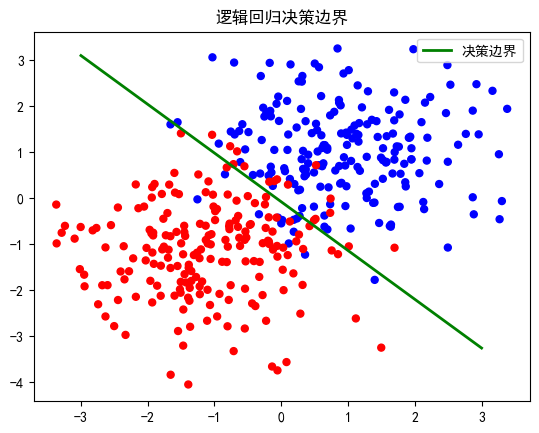

In [16]:
# 6.2 逻辑回归二分类（手动实现）
import numpy as np
import matplotlib.pyplot as plt

# 解决中文乱码问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'WenQuanYi Zen Hei']  # 优先使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

# 1. 生成二分类数据
np.random.seed(0)
X1 = np.random.randn(200, 2) + [1, 1]   # 类别 0
X2 = np.random.randn(200, 2) + [-1, -1] # 类别 1
X = np.vstack((X1, X2))
y = np.hstack((np.zeros(200), np.ones(200)))

# 2. 生成测试集
X_test = np.vstack((np.random.randn(50,2)+[1,1], np.random.randn(50,2)+[-1,-1]))
y_test = np.hstack((np.zeros(50), np.ones(50)))

# 3. 定义 Sigmoid 激活函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 4. 初始化参数
w = np.zeros(2)
b = 0.0
lr = 0.1
epochs = 1000

# 5. 梯度下降训练
for _ in range(epochs):
    # 前向传播
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)

    # 计算梯度
    dz = y_pred - y
    dw = np.dot(X.T, dz) / len(X)
    db = np.mean(dz)

    # 更新参数
    w -= lr * dw
    b -= lr * db

# 6. 测试集评估
y_pred_test = sigmoid(np.dot(X_test, w) + b)
acc = np.mean((y_pred_test > 0.5) == y_test)
print("逻辑回归测试集准确率：", acc)

# 7. 绘制决策边界
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=25)
x1 = np.linspace(-3, 3, 100)
x2 = -(w[0] * x1 + b) / w[1]
plt.plot(x1, x2, 'g-', lw=2, label='决策边界')
plt.title('逻辑回归决策边界')
plt.legend()
plt.show()